# Data Quality & Defensible Decision System — Olist Marketplace

**Thesis: a dashboard is only as useful as the data behind it.**

This notebook is the working analysis behind the report. It is deliberately ordered the way I actually
worked the problem, so the reasoning is visible end to end:

1. **Load** the nine raw Olist tables (read-only).
2. **Check for signal first** — confirm the data carries real relationships before trusting any analysis.
3. **Audit the three engineering hazards** that would silently break every per-order metric.
4. **Build the decision-ready, order-grain tables** and the derived fields.
5. **Analyse** — eight figures, each with *Signal / Analysis / So What / Caveat*.
6. **AI-augmented step** — classify review text, but **validated** against an independent pass and the star ratings.
7. **Reconcile** raw vs decision-ready and state the limits.

> **Decision question.** Where should the marketplace focus to protect revenue and customer satisfaction —
> and are the numbers trustworthy enough to act on? Stakeholders: operations, category management, CX, and the BI/data team.
>
> **Data.** Olist Brazilian E-Commerce (Kaggle `olistbr/brazilian-ecommerce`), real and anonymized, ~100k orders, 2016–2018, CC BY-NC 4.0.
> The raw CSVs are not committed; download them into `data/raw/`. The polished write-up with embedded figures is `reports/Olist_Analyst_Report.docx`.

## 1 · Load the raw tables

One row per order in `orders`; **fan-out** in `order_items` (one row per item) and `order_payments`
(one row per installment). We parse the five order timestamps up front.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ROOT = Path.cwd()
RAW, CLEAN, OUT = ROOT/"data"/"raw", ROOT/"data"/"cleaned", ROOT/"data"/"output"
CLEAN.mkdir(parents=True, exist_ok=True); OUT.mkdir(parents=True, exist_ok=True)
CH = ROOT/"reports"/"charts"; CH.mkdir(parents=True, exist_ok=True)
pd.options.display.float_format = lambda v: f"{v:,.2f}"

load = lambda n: pd.read_csv(RAW/n)
orders    = load("olist_orders_dataset.csv")
items     = load("olist_order_items_dataset.csv")
payments  = load("olist_order_payments_dataset.csv")
reviews   = load("olist_order_reviews_dataset.csv")
products  = load("olist_products_dataset.csv")
sellers   = load("olist_sellers_dataset.csv")
customers = load("olist_customers_dataset.csv")
geo       = load("olist_geolocation_dataset.csv")
cat_xlate = load("product_category_name_translation.csv")

for c in ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
          "order_delivered_customer_date","order_estimated_delivery_date"]:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

pd.DataFrame({"table": ["orders","order_items","order_payments","order_reviews","products",
                        "sellers","customers","geolocation","category_translation"],
              "rows": [len(orders),len(items),len(payments),len(reviews),len(products),
                       len(sellers),len(customers),len(geo),len(cat_xlate)],
              "cols": [orders.shape[1],items.shape[1],payments.shape[1],reviews.shape[1],
                       products.shape[1],sellers.shape[1],customers.shape[1],geo.shape[1],cat_xlate.shape[1]]})

FileNotFoundError: [Errno 2] No such file or directory: '/Users/macpro/Downloads/olist-data-quality-decision-system/data/raw/olist_orders_dataset.csv'

## 2 · Signal check — *before* trusting anything

A previous project taught me an expensive lesson: a dataset can look clean and still be analytically dead
(uncorrelated noise). So the first thing I do on any new data is confirm it carries **real signal** —
relationships that *must* exist if the data is genuine. If these fail, I stop. Here I check three:

- order value (items + freight) vs amount actually paid — should be ~1.0;
- delivery time vs review score — should be **negative** (slow delivery → unhappy customer);
- monthly orders — should show real seasonality, not a flat line.

In [ ]:
# (a) order value vs payment — must be ~1.0
iv = items.groupby("order_id").agg(items_total=("price","sum"), freight=("freight_value","sum"))
iv["order_value"] = iv["items_total"] + iv["freight"]
pay_tot = payments.groupby("order_id")["payment_value"].sum().rename("pay_total")
m = iv.join(pay_tot, how="inner")
r_pay = m["order_value"].corr(m["pay_total"])

# (b) delivery days vs review score — must be negative
od = orders.copy()
od["delivery_days"] = (od["order_delivered_customer_date"] - od["order_purchase_timestamp"]).dt.total_seconds()/86400
ds = (od[["order_id","delivery_days"]].merge(reviews[["order_id","review_score"]], on="order_id")
        .dropna())
r_score = ds["delivery_days"].corr(ds["review_score"])

# (c) seasonality
od["ym"] = od["order_purchase_timestamp"].dt.to_period("M").astype(str)
mo = od[od["order_status"].eq("delivered")].groupby("ym").size()

print(f"(a) order value vs payment        r = {r_pay:.3f}   (expect ~1.00)")
print(f"(b) delivery days vs review score r = {r_score:.3f}  (expect negative)")
print(f"    median delivery {ds['delivery_days'].median():.1f} d, mean score {ds['review_score'].mean():.2f}")
print(f"(c) months {mo.index.min()}–{mo.index.max()} ({len(mo)} months); peak {mo.idxmax()} = {mo.max():,}")
print(f"    reviews with free text: {reviews['review_comment_message'].notna().sum():,} of {len(reviews):,}")
print("\nVerdict: real signal on all three -> safe to proceed.")

(a) order value vs payment        r = 1.000   (expect ~1.00)
(b) delivery days vs review score r = -0.334  (expect negative)
    median delivery 10.2 d, mean score 4.16
(c) months 2016-09–2018-08 (23 months); peak 2017-11 = 7,289
    reviews with free text: 40,977 of 99,224

Verdict: real signal on all three -> safe to proceed.


## 3 · The three engineering hazards

Profiling surfaced three structural traps. None is a "dirty cell" you can spot by eye; each would quietly
corrupt headline numbers if you joined the tables naïvely. This is the heart of the data-quality story.

### Hazard A — fan-out double-counting
`order_items` has one row per **item** and `order_payments` one row per **installment**. Join
`orders × items × payments` and every order's revenue is repeated once per extra row. Below: the naïve join
versus the truth (aggregate to order grain first).

In [ ]:
naive = (orders.merge(items, on="order_id", how="inner")
               .merge(payments, on="order_id", how="inner"))
gmv_true = items["price"].sum()
pay_true = payments["payment_value"].sum()
multi_item = (items.groupby("order_id").size() > 1).sum()
multi_pay  = (payments.groupby("order_id").size() > 1).sum()

print(f"orders with >1 item    : {multi_item:,} (max {items.groupby('order_id').size().max()})")
print(f"orders with >1 payment : {multi_pay:,} (max {payments.groupby('order_id').size().max()})")
print(f"\nnaive join rows                : {len(naive):,}")
print(f"product revenue  naive vs true : R$ {naive['price'].sum():,.0f}  vs  R$ {gmv_true:,.0f}"
      f"   (+{(naive['price'].sum()/gmv_true-1)*100:.0f}%)")
print(f"cash collected   naive vs true : R$ {naive['payment_value'].sum():,.0f}  vs  R$ {pay_true:,.0f}"
      f"   (+{(naive['payment_value'].sum()/pay_true-1)*100:.0f}%)")
print("\n-> never join raw; aggregate items & payments to ORDER grain first.")

orders with >1 item    : 9,803 (max 21)
orders with >1 payment : 2,961 (max 29)

naive join rows                : 117,601
product revenue  naive vs true : R$ 14,209,115  vs  R$ 13,591,644   (+5%)
cash collected   naive vs true : R$ 20,308,135  vs  R$ 16,008,872   (+27%)

-> never join raw; aggregate items & payments to ORDER grain first.


### Hazard B — geolocation duplication
The geolocation table has ~1M rows for only ~19k zip prefixes. Joined as-is it would explode any
geographic view, so we collapse it to **one row per prefix** (mean lat/lng, modal city/state).

In [ ]:
def fast_mode(df, key, col):
    g = df.groupby([key, col]).size().reset_index(name="n")
    return g.sort_values("n").drop_duplicates(key, keep="last").set_index(key)[col]

geo_clean = (geo.groupby("geolocation_zip_code_prefix")
               .agg(lat=("geolocation_lat","mean"), lng=("geolocation_lng","mean"))
               .join(fast_mode(geo,"geolocation_zip_code_prefix","geolocation_city").rename("city"))
               .join(fast_mode(geo,"geolocation_zip_code_prefix","geolocation_state").rename("state"))
               .reset_index().rename(columns={"geolocation_zip_code_prefix":"zip_prefix"}))
print(f"{len(geo):,} geo rows -> {len(geo_clean):,} unique prefixes")

1,000,163 geo rows -> 19,015 unique prefixes


### Hazard C — customer identity
`customer_id` is **per order**: Olist mints a new one for every purchase. The real person is
`customer_unique_id`. Any retention or RFM work must key on the latter — otherwise every customer looks new
and the repeat rate is mechanically zero.

In [ ]:
print(f"customer_id (per order) : {customers['customer_id'].nunique():,}")
print(f"customer_unique_id (real): {customers['customer_unique_id'].nunique():,}")

customer_id (per order) : 99,441
customer_unique_id (real): 96,096


## 4 · Build the decision-ready tables

Now the cleaning, applying all three fixes and engineering the fields the analysis needs:
product categories mapped to English (with manual labels for the two the lookup misses, and an
`unknown` bucket for the 610 with no category), items & payments aggregated to order grain,
order-level derived fields (`order_value`, `delivery_days`, `is_late`, `delivered`, …), and
**RFM keyed on `customer_unique_id`**. Cleaned tables are written to `data/cleaned/` (raw is never touched).

In [ ]:
BRL = 2
MANUAL_CATEGORY_EN = {"pc_gamer":"gaming_pc",
                      "portateis_cozinha_e_preparadores_de_alimentos":"portable_kitchen_and_food_preparers"}

# products -> english category
products_clean = products.merge(cat_xlate, on="product_category_name", how="left")
mm = products_clean["product_category_name"].isin(MANUAL_CATEGORY_EN)
products_clean.loc[mm,"product_category_name_english"] = products_clean.loc[mm,"product_category_name"].map(MANUAL_CATEGORY_EN)
products_clean["category_en"] = products_clean["product_category_name_english"].fillna("unknown")
products_clean = products_clean[["product_id","product_category_name","category_en"]]

# Hazard A — aggregate to order grain
item_agg = items.groupby("order_id").agg(order_product_revenue=("price","sum"),
            order_freight=("freight_value","sum"), n_items=("order_item_id","count"),
            n_sellers=("seller_id","nunique"))
pay_agg = payments.groupby("order_id").agg(order_payment_total=("payment_value","sum"),
            n_payments=("payment_value","size"), n_installments=("payment_installments","max"))
main_type = (payments.sort_values("payment_value").drop_duplicates("order_id", keep="last")
             .set_index("order_id")["payment_type"].rename("main_payment_type"))
rev_flag = reviews.assign(has_text=reviews["review_comment_message"].notna())
rev_agg = rev_flag.groupby("order_id").agg(review_score=("review_score","mean"),
            n_reviews=("review_id","size"), review_has_text=("has_text","max"))

# order-grain table + derived fields
oc = orders.merge(customers[["customer_id","customer_unique_id","customer_zip_code_prefix",
                             "customer_city","customer_state"]], on="customer_id", how="left")
oc = (oc.join(item_agg, on="order_id").join(pay_agg, on="order_id")
        .join(main_type, on="order_id").join(rev_agg, on="order_id"))
oc["has_items"]   = oc["order_product_revenue"].notna()
oc["has_payment"] = oc["order_payment_total"].notna()
for c in ["order_product_revenue","order_freight","n_items","n_sellers"]:
    oc[c] = oc[c].fillna(0)
oc["order_value"]  = oc["order_product_revenue"] + oc["order_freight"]
oc["delivered"]    = oc["order_status"].eq("delivered")
oc["delivery_days"]= (oc["order_delivered_customer_date"]-oc["order_purchase_timestamp"]).dt.total_seconds()/86400
dk = oc["order_delivered_customer_date"].notna()
oc["is_late"] = np.where(dk, oc["order_delivered_customer_date"]>oc["order_estimated_delivery_date"], np.nan)
oc["purchase_ym"] = oc["order_purchase_timestamp"].dt.to_period("M").astype(str)
oc["review_has_text"] = oc["review_has_text"].fillna(0).astype(int)

# Hazard C — RFM on customer_unique_id
ref_date = oc["order_purchase_timestamp"].max()
rfm = oc.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda s:(ref_date-s.max()).days),
    frequency=("order_id","nunique"), monetary=("order_value","sum")).reset_index()
rfm["R_score"] = pd.qcut(rfm["recency_days"].rank(method="first"),5,labels=[5,4,3,2,1]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"),5,labels=[1,2,3,4,5]).astype(int)
rfm["is_repeat"] = rfm["frequency"] >= 2
def segment(r):
    if r.frequency>=2: return "Repeat (Loyal/Champion)"
    if r.R_score>=4 and r.M_score>=4: return "New high-value"
    if r.R_score>=4: return "New / recent"
    if r.R_score<=2 and r.M_score>=4: return "Dormant high-value"
    if r.R_score<=2: return "Dormant"
    return "Mid one-time"
rfm["segment"] = rfm.apply(segment, axis=1)

items_clean = items.merge(products_clean[["product_id","category_en"]], on="product_id", how="left")
items_clean["category_en"] = items_clean["category_en"].fillna("unknown")

for df,name in [(oc,"orders_clean"),(geo_clean,"geo_clean"),(products_clean,"products_clean"),
                (rfm,"customer_rfm"),(items_clean,"order_items_clean")]:
    df.to_csv(CLEAN/f"{name}.csv", index=False)
print("cleaned tables written:", ", ".join(sorted(p.name for p in CLEAN.glob("*.csv"))))
print(f"order-grain rows: {len(oc):,}")

cleaned tables written: customer_rfm.csv, geo_clean.csv, order_items_clean.csv, orders_clean.csv, products_clean.csv
order-grain rows: 99,441


## 5 · Headline KPIs (decision-ready)

These come straight from the order-grain table, so they are immune to the fan-out double-count.
Revenue is reported two ways — **GMV** (all product revenue) and **net** (delivered orders only) —
and the same aggregates are written to `data/output/` for Tableau and the report.

In [ ]:
with_items = oc[oc["has_items"]].copy()
delivered  = oc[oc["delivered"]].copy()
deliv_known= oc[oc["order_delivered_customer_date"].notna()].copy()

gmv = with_items["order_product_revenue"].sum()
net_rev = delivered["order_product_revenue"].sum()
n_orders = oc["order_id"].nunique(); n_delivered = int(oc["delivered"].sum())
kpi = pd.DataFrame([
    ("GMV (product revenue, BRL)", round(gmv,BRL)),
    ("Net product revenue, delivered (BRL)", round(net_rev,BRL)),
    ("Freight (BRL)", round(with_items["order_freight"].sum(),BRL)),
    ("Total orders", n_orders),
    ("Delivered orders", n_delivered),
    ("% delivered", round(n_delivered/n_orders*100,2)),
    ("AOV net (BRL/delivered order)", round(net_rev/n_delivered,BRL)),
    ("On-time delivery rate (%)", round((~deliv_known["is_late"].astype(bool)).mean()*100,2)),
    ("Median delivery days", round(deliv_known["delivery_days"].median(),2)),
    ("P90 delivery days", round(deliv_known["delivery_days"].quantile(.90),2)),
    ("Unique customers (customer_unique_id)", rfm.shape[0]),
    ("Repeat-customer rate (%)", round(rfm["is_repeat"].mean()*100,2)),
    ("% reviews with text", round(reviews["review_comment_message"].notna().mean()*100,2)),
], columns=["kpi","value"])
kpi.to_csv(OUT/"kpi_summary.csv", index=False)
kpi

,kpi,value
0,"GMV (product revenue, BRL)","13,591,643.70"
1,"Net product revenue, delivered (BRL)","13,221,498.11"
2,Freight (BRL),"2,251,909.54"
3,Total orders,"99,441.00"
4,Delivered orders,"96,478.00"
5,% delivered,97.02
6,AOV net (BRL/delivered order),137.04
7,On-time delivery rate (%),91.89
8,Median delivery days,10.22
9,P90 delivery days,23.10


In [ ]:
# ---- build the rest of the Tableau-ready aggregates (same as the pipeline) ----
# 1 monthly
monthly = with_items.groupby("purchase_ym").agg(orders=("order_id","nunique"), gmv=("order_product_revenue","sum")).reset_index()
monthly = monthly.merge(delivered.groupby("purchase_ym").agg(delivered_orders=("order_id","nunique")).reset_index(), on="purchase_ym", how="left")
monthly["gmv"] = monthly["gmv"].round(BRL); monthly.to_csv(OUT/"monthly_trend.csv", index=False)
# 2 category pareto
cat_rev = (items_clean.groupby("category_en")["price"].sum().sort_values(ascending=False).reset_index().rename(columns={"price":"revenue"}))
cat_rev["revenue"]=cat_rev["revenue"].round(BRL); cat_rev["pct"]=cat_rev["revenue"]/cat_rev["revenue"].sum()*100
cat_rev["cum_pct"]=cat_rev["pct"].cumsum(); cat_rev["rank"]=np.arange(1,len(cat_rev)+1); cat_rev.to_csv(OUT/"category_revenue_pareto.csv", index=False)
# 3 delivery distribution
bins=[0,5,10,15,20,25,30,40,60,np.inf]; labels=["0-5","5-10","10-15","15-20","20-25","25-30","30-40","40-60","60+"]
dd=deliv_known.copy(); dd["bucket"]=pd.cut(dd["delivery_days"],bins=bins,labels=labels,right=False)
delivery_dist=dd.groupby("bucket",observed=False).agg(orders=("order_id","nunique")).reset_index()
delivery_dist["pct"]=delivery_dist["orders"]/delivery_dist["orders"].sum()*100; delivery_dist.to_csv(OUT/"delivery_distribution.csv", index=False)
# 4 score vs delivery
score_delay=(deliv_known.dropna(subset=["review_score"]).assign(score=lambda d:d["review_score"].round().astype(int))
    .groupby("score").agg(mean_delivery_days=("delivery_days","mean"), median_delivery_days=("delivery_days","median"),
    late_rate=("is_late", lambda s:s.astype(float).mean()*100), n=("order_id","nunique")).reset_index())
for c in ["mean_delivery_days","median_delivery_days","late_rate"]: score_delay[c]=score_delay[c].round(2)
score_delay.to_csv(OUT/"score_vs_delivery.csv", index=False)
r_score_final = deliv_known.dropna(subset=["review_score"])["delivery_days"].corr(deliv_known.dropna(subset=["review_score"])["review_score"])
# 5 rfm segments + repeat
seg=(rfm.groupby("segment").agg(customers=("customer_unique_id","nunique"), avg_monetary=("monetary","mean"),
    avg_frequency=("frequency","mean"), avg_recency=("recency_days","mean")).reset_index().sort_values("customers",ascending=False))
seg["pct_customers"]=(seg["customers"]/seg["customers"].sum()*100).round(2)
seg["avg_monetary"]=seg["avg_monetary"].round(2); seg["avg_frequency"]=seg["avg_frequency"].round(3); seg["avg_recency"]=seg["avg_recency"].round(1)
seg.to_csv(OUT/"rfm_segments.csv", index=False)
fb=rfm["frequency"].apply(lambda f:"1" if f==1 else ("2" if f==2 else "3+"))
repeat=(rfm.assign(freq_bucket=fb).groupby("freq_bucket").agg(customers=("customer_unique_id","nunique"), revenue=("monetary","sum")).reset_index())
repeat["pct_customers"]=(repeat["customers"]/repeat["customers"].sum()*100).round(2)
repeat["pct_revenue"]=(repeat["revenue"]/repeat["revenue"].sum()*100).round(2); repeat["revenue"]=repeat["revenue"].round(2)
repeat.to_csv(OUT/"repeat_summary.csv", index=False)
# 6 state
state_rev=(with_items.groupby("customer_state").agg(gmv=("order_product_revenue","sum"), orders=("order_id","nunique"),
    customers=("customer_unique_id","nunique")).reset_index().sort_values("gmv",ascending=False))
state_rev["gmv"]=state_rev["gmv"].round(2); state_rev["pct_gmv"]=(state_rev["gmv"]/state_rev["gmv"].sum()*100).round(2)
state_rev.to_csv(OUT/"revenue_by_state.csv", index=False)
# 7 reconciliation
recon=pd.DataFrame([
  ("Join rows used for revenue", len(naive), with_items.shape[0], "orders x items x payments explodes; correct view is one row per order"),
  ("Product revenue (sum price, BRL)", round(naive["price"].sum(),2), round(gmv,2), "price repeated once per payment row in the naive join"),
  ("Cash collected (sum payment_value, BRL)", round(naive["payment_value"].sum(),2), round(payments["payment_value"].sum(),2), "payment_value repeated once per item row"),
  ("AOV (BRL per order)", round(naive["price"].sum()/naive["order_id"].nunique(),2), round(gmv/with_items["order_id"].nunique(),2), "naive AOV inflated by the same double-count"),
], columns=["metric","naive_raw","decision_ready","why"])
recon["inflation_pct"]=((recon["naive_raw"]-recon["decision_ready"])/recon["decision_ready"]*100).round(2)
recon.to_csv(OUT/"reconciliation.csv", index=False)
print("data/output/:", ", ".join(sorted(p.name for p in OUT.glob("*.csv"))))
print(f"r(delivery_days, review_score) = {r_score_final:.4f}")

data/output/: ai_sentiment_by_topic.csv, ai_topic_breakdown.csv, category_revenue_pareto.csv, delivery_distribution.csv, kpi_summary.csv, monthly_trend.csv, reconciliation.csv, repeat_summary.csv, revenue_by_state.csv, rfm_segments.csv, score_vs_delivery.csv
r(delivery_days, review_score) = -0.3343


## 6 · Findings

Eight figures. Each chart is evidence for one claim (an action title), and each is followed by
**Signal / Analysis / So What / Caveat** — the same discipline the written report uses.

In [ ]:
# shared chart style (matches the report figures)
BLUE, HI, GRAY, GREEN = "#3B6FA0", "#D1495B", "#9aa0a6", "#3f8f5b"
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":150,"font.size":11,"font.family":"sans-serif",
    "axes.titlesize":13,"axes.titleweight":"bold","axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.color":"#e6e6e6","grid.linewidth":0.8,"axes.axisbelow":True})
millions = lambda x,_: (f"R${x/1e6:g}M" if x>=1e6 else f"R${x/1e3:.0f}k")
def savefig(fig, name): fig.savefig(CH/name, bbox_inches="tight", facecolor="white"); 
kpi_s = kpi.set_index("kpi")["value"]

### Figure 1 — Demand is seasonal; orders peak every November
- **Signal.** Orders climb through 2017 and spike in **November 2017** (Black-Friday season).
- **Analysis.** Growth is real but front-loaded into a few high-volume months; the edge months are partial and flagged.
- **So What.** Staffing, inventory, and carrier capacity should be planned against the Nov peak, not the annual average.
- **Caveat.** First/last months are partial; this is a 2016–2018 window, not a forecast.

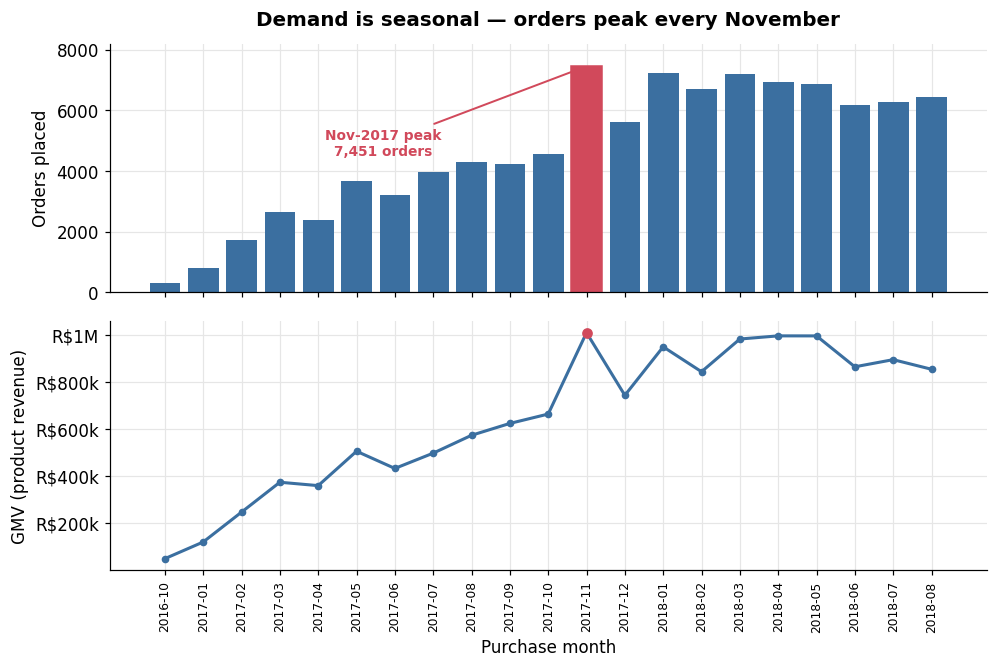

In [ ]:
m = pd.read_csv(OUT/"monthly_trend.csv"); m = m[m["orders"]>=50].reset_index(drop=True)
x=range(len(m)); peak=m["orders"].idxmax()
fig,(a1,a2)=plt.subplots(2,1,figsize=(9.2,6.2),sharex=True)
bars=a1.bar(x,m["orders"],color=BLUE); bars[peak].set_color(HI)
a1.set_ylim(0,m["orders"].max()*1.10); a1.set_title("Demand is seasonal — orders peak every November",pad=12); a1.set_ylabel("Orders placed")
a1.annotate(f"Nov-2017 peak\n{int(m.loc[peak,'orders']):,} orders", xy=(peak,m.loc[peak,"orders"]),
            xytext=(peak-5.3,m["orders"].max()*0.66), ha="center",va="center",fontsize=9,color=HI,fontweight="bold",
            arrowprops=dict(arrowstyle="->",color=HI,lw=1.3))
a2.plot(x,m["gmv"],color=BLUE,marker="o",ms=4,lw=2); a2.scatter([peak],[m.loc[peak,"gmv"]],color=HI,zorder=5)
a2.set_ylabel("GMV (product revenue)"); a2.yaxis.set_major_formatter(FuncFormatter(millions))
a2.set_xticks(list(x)); a2.set_xticklabels(m["purchase_ym"],rotation=90,fontsize=8); a2.set_xlabel("Purchase month")
fig.tight_layout(); savefig(fig,"fig1_monthly_trend.png"); plt.show()

### Figure 2 — Revenue concentrates in a handful of categories
- **Signal.** A small number of categories produce ~80% of revenue (the cumulative line crosses 80% early).
- **Analysis.** Classic Pareto concentration — a few categories carry the marketplace.
- **So What.** Category managers should protect supply, pricing, and delivery SLAs on the top cluster first.
- **Caveat.** Revenue ≠ margin (no cost data); `unknown` holds the 610 products with no category.

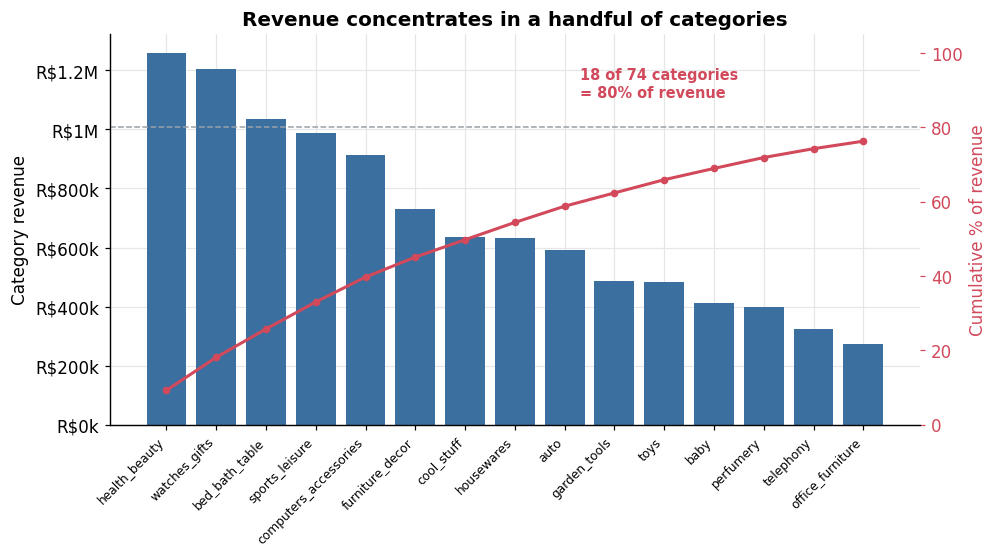

In [ ]:
c=pd.read_csv(OUT/"category_revenue_pareto.csv"); top=c.head(15); n80=int((c["cum_pct"]<=80).sum())+1
fig,ax=plt.subplots(figsize=(9.2,5.2)); ax.bar(range(len(top)),top["revenue"],color=BLUE)
ax.set_ylabel("Category revenue"); ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax.set_xticks(range(len(top))); ax.set_xticklabels(top["category_en"],rotation=45,ha="right",fontsize=8)
ax.set_title("Revenue concentrates in a handful of categories")
ax2=ax.twinx(); ax2.plot(range(len(top)),top["cum_pct"],color=HI,marker="o",ms=4,lw=2); ax2.axhline(80,color=GRAY,ls="--",lw=1)
ax2.set_ylabel("Cumulative % of revenue",color=HI); ax2.set_ylim(0,105); ax2.grid(False); ax2.tick_params(axis="y",colors=HI)
ax2.text(0.58,0.84,f"{n80} of {len(c)} categories\n= 80% of revenue",transform=ax2.transAxes,fontsize=9.5,color=HI,fontweight="bold",ha="left")
fig.tight_layout(); savefig(fig,"fig2_category_pareto.png"); plt.show()

### Figure 3 — Most parcels arrive in ~10 days, but a long tail drags satisfaction
- **Signal.** Median delivery ≈ 10 days; a meaningful tail stretches past 20–30 days.
- **Analysis.** The centre is healthy; the tail is where dissatisfaction is generated (see Figure 4).
- **So What.** Target the slowest decile rather than the average — that is where ratings are lost.
- **Caveat.** Only delivered orders with both timestamps; undelivered/cancelled excluded.

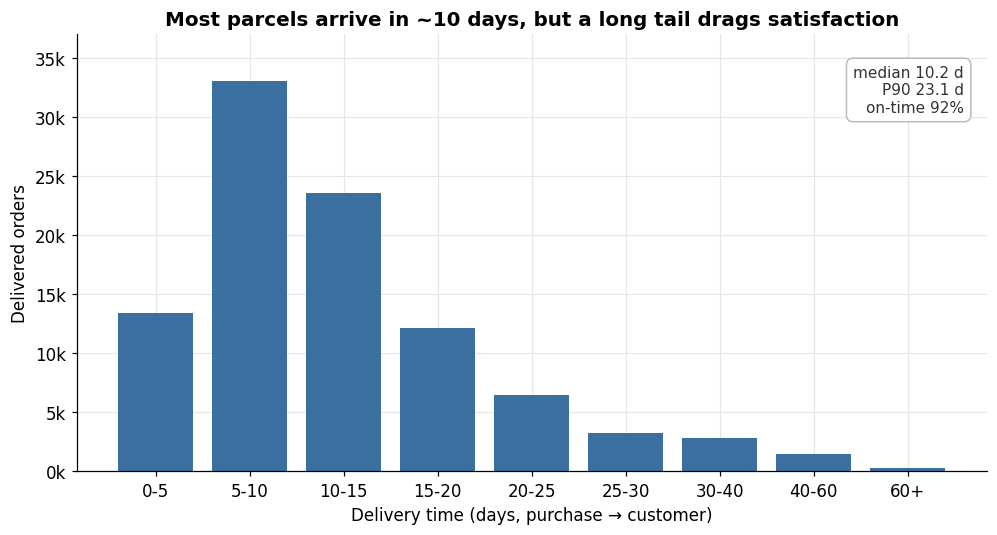

In [ ]:
d=pd.read_csv(OUT/"delivery_distribution.csv")
med=kpi_s["Median delivery days"]; p90=kpi_s["P90 delivery days"]; ontime=kpi_s["On-time delivery rate (%)"]
fig,ax=plt.subplots(figsize=(9.2,5.0)); ax.bar(d["bucket"].astype(str),d["orders"],color=BLUE)
ax.set_xlabel("Delivery time (days, purchase → customer)"); ax.set_ylabel("Delivered orders")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_:f"{v/1e3:.0f}k")); ax.set_ylim(0,d["orders"].max()*1.12)
ax.set_title("Most parcels arrive in ~10 days, but a long tail drags satisfaction")
ax.text(0.975,0.93,f"median {med:.1f} d\nP90 {p90:.1f} d\non-time {ontime:.0f}%",transform=ax.transAxes,ha="right",va="top",
        fontsize=10,color="#333333",bbox=dict(boxstyle="round,pad=0.45",fc="white",ec="#bbbbbb",lw=1))
fig.tight_layout(); savefig(fig,"fig3_delivery_distribution.png"); plt.show()

### Figure 4 — Late delivery is the strongest observed operational signal associated with low review scores (r = −0.334)
- **Signal.** 1-star orders waited far longer than 5-star orders; the correlation is −0.33.
- **Analysis.** Of the structured operational signals available, delivery time has the clearest association with satisfaction.
- **So What.** Cutting the delivery tail is a high-priority operational lever to test — supported by the text evidence in Figure 8.
- **Caveat.** Strong association, **not proof of cause**; price, category, and expectations also matter.

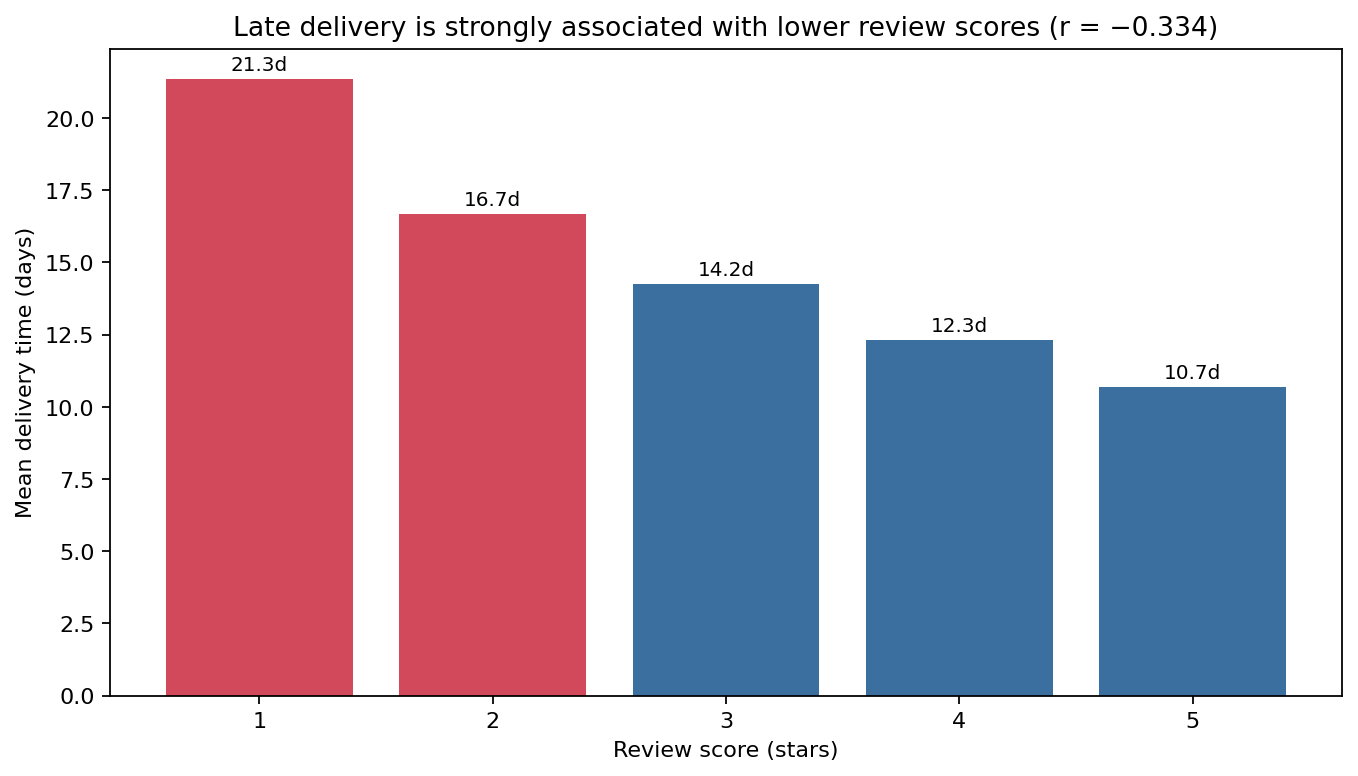

In [ ]:
s=pd.read_csv(OUT/"score_vs_delivery.csv")
fig,ax=plt.subplots(figsize=(8.6,5.0)); colors=[HI if sc<=2 else BLUE for sc in s["score"]]
ax.bar(s["score"],s["mean_delivery_days"],color=colors)
for _,row in s.iterrows():
    ax.annotate(f"{row['mean_delivery_days']:.1f}d",(row["score"],row["mean_delivery_days"]),textcoords="offset points",xytext=(0,4),ha="center",fontsize=9)
ax.set_xlabel("Review score (stars)"); ax.set_ylabel("Mean delivery time (days)")
ax.set_title("Late delivery is strongly associated with lower review scores (r = −0.334)"); ax.set_xticks([1,2,3,4,5])
fig.tight_layout(); savefig(fig,"fig4_score_vs_delivery.png"); plt.show()

### Figure 5 — Only ~3% of customers come back — an acquisition engine, not a retention engine
- **Signal.** The overwhelming majority of `customer_unique_id`s order once; repeat buyers are a thin slice of both customers and revenue.
- **Analysis.** Growth has been acquisition-led; there is little repeat base to lean on.
- **So What.** A retention/post-purchase program is upside that barely exists today — but judge it against this low base.
- **Caveat.** A two-year window understates lifetime repeat; identity resolved via `customer_unique_id`.

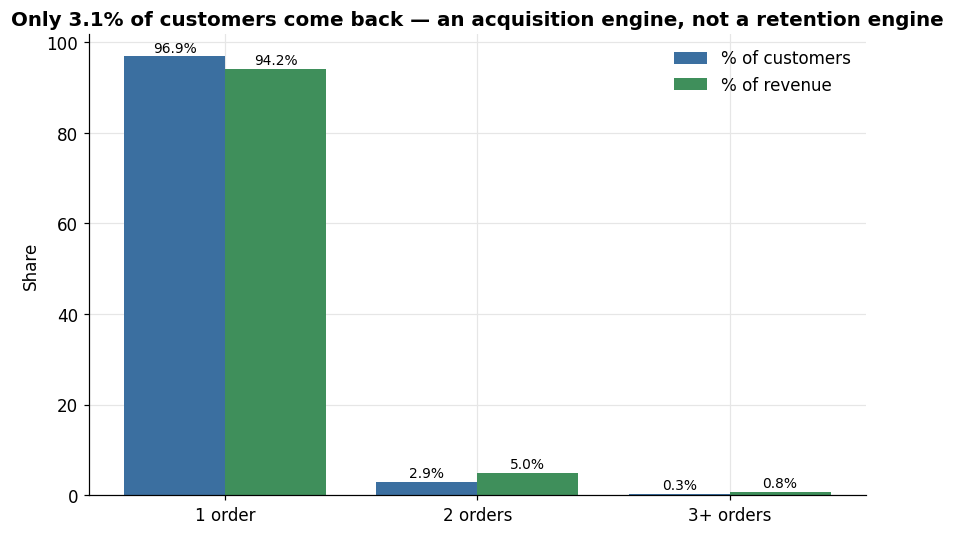

In [ ]:
r=pd.read_csv(OUT/"repeat_summary.csv").set_index("freq_bucket").reindex(["1","2","3+"]).reset_index()
rr=kpi_s["Repeat-customer rate (%)"]
fig,ax=plt.subplots(figsize=(8.0,5.0)); xb=range(len(r))
b1=ax.bar([i-0.2 for i in xb],r["pct_customers"],width=0.4,color=BLUE,label="% of customers")
b2=ax.bar([i+0.2 for i in xb],r["pct_revenue"],width=0.4,color=GREEN,label="% of revenue")
for bars in (b1,b2):
    for rect in bars:
        ax.annotate(f"{rect.get_height():.1f}%",(rect.get_x()+rect.get_width()/2,rect.get_height()),textcoords="offset points",xytext=(0,3),ha="center",fontsize=9)
ax.set_xticks(list(xb)); ax.set_xticklabels(["1 order","2 orders","3+ orders"]); ax.set_ylabel("Share")
ax.set_title(f"Only {rr:.1f}% of customers come back — an acquisition engine, not a retention engine"); ax.legend(frameon=False)
fig.tight_layout(); savefig(fig,"fig5_repeat_behaviour.png"); plt.show()

### Figure 6 — Demand concentrates in São Paulo
- **Signal.** SP is the single largest state by a wide margin.
- **Analysis.** Revenue is geographically concentrated; the South-East dominates.
- **So What.** Regional logistics and marketing should be weighted to SP/South-East; other states are expansion headroom.
- **Caveat.** Reflects Olist's seller/buyer base in 2016–2018; not the Brazilian e-commerce market overall.

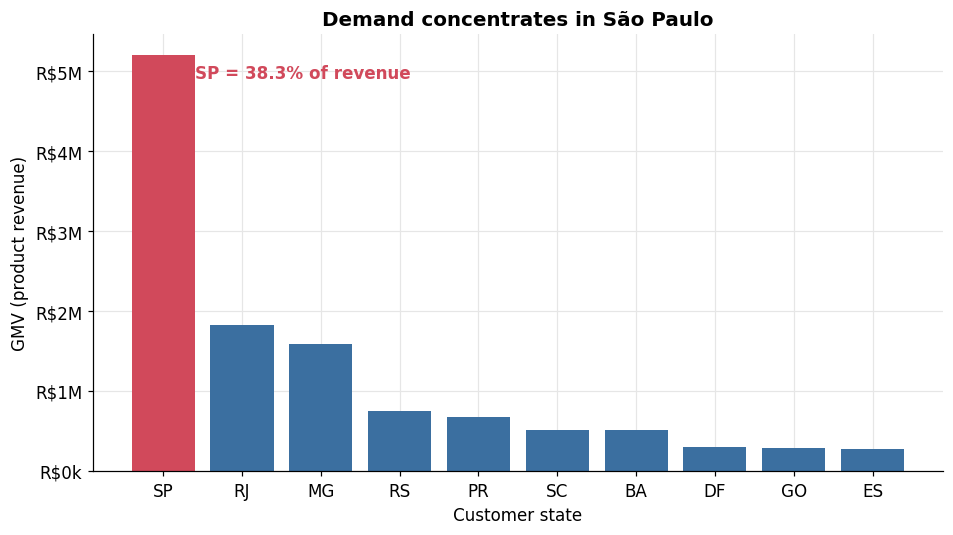

In [ ]:
st=pd.read_csv(OUT/"revenue_by_state.csv").head(10)
fig,ax=plt.subplots(figsize=(8.8,5.0)); colors=[HI if s=="SP" else BLUE for s in st["customer_state"]]
ax.bar(st["customer_state"],st["gmv"],color=colors); ax.set_ylabel("GMV (product revenue)")
ax.yaxis.set_major_formatter(FuncFormatter(millions)); ax.set_xlabel("Customer state")
sp=st[st["customer_state"]=="SP"].iloc[0]; ax.set_title("Demand concentrates in São Paulo")
ax.text(0.12,0.90,f"SP = {sp['pct_gmv']:.1f}% of revenue",transform=ax.transAxes,color=HI,fontweight="bold",ha="left")
fig.tight_layout(); savefig(fig,"fig6_revenue_by_state.png"); plt.show()

### Figure 7 — A naïve join double-counts revenue; the grain has to be fixed first
- **Signal.** The raw `orders × items × payments` join inflates both product revenue and cash collected versus the order-grain truth.
- **Analysis.** This is Hazard A made visible — the single most important reason to build a data-quality layer before a dashboard.
- **So What.** Every per-order KPI in this project is computed on the corrected grain; a dashboard built on the raw join would mislead leadership.
- **Caveat.** The inflation % is specific to this dataset's fan-out; the principle is general.

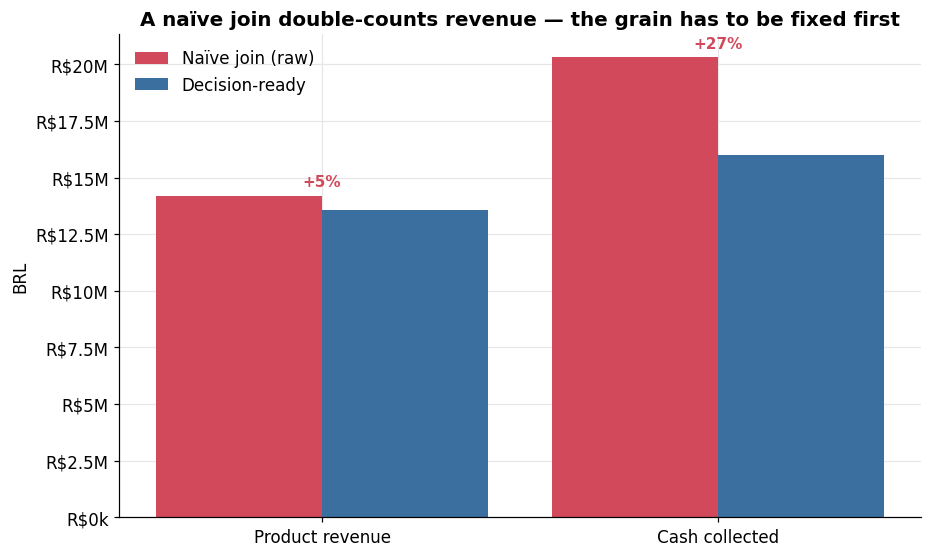

In [ ]:
rc=pd.read_csv(OUT/"reconciliation.csv")
money=rc.set_index("metric").loc[["Product revenue (sum price, BRL)","Cash collected (sum payment_value, BRL)"]].reset_index()
fig,ax=plt.subplots(figsize=(8.6,5.2)); xb=range(len(money))
ax.bar([i-0.21 for i in xb],money["naive_raw"],width=0.42,color=HI,label="Naïve join (raw)")
ax.bar([i+0.21 for i in xb],money["decision_ready"],width=0.42,color=BLUE,label="Decision-ready")
ax.set_xticks(list(xb)); ax.set_xticklabels(["Product revenue","Cash collected"]); ax.set_ylabel("BRL")
ax.yaxis.set_major_formatter(FuncFormatter(millions)); ax.set_title("A naïve join double-counts revenue — the grain has to be fixed first")
for i,(_,row) in enumerate(money.iterrows()):
    ax.annotate(f"+{row['inflation_pct']:.0f}%",(i,max(row['naive_raw'],row['decision_ready'])),textcoords="offset points",xytext=(0,6),ha="center",color=HI,fontweight="bold",fontsize=10)
ax.legend(frameon=False); fig.tight_layout(); savefig(fig,"fig7_raw_vs_decision_ready.png"); plt.show()

## 7 · AI-augmented step — validated, not trusted blindly

40,977 reviews carry free-text comments (Portuguese). I used an LLM to classify a reproducible random
**sample of 1,000** into topic (delivery / product / price / service / other) and sentiment — then treated
the output as a *claim to be validated*, not as truth. This classification + validation runs as a separate,
reproducible script (`scripts/ai_sample.py` → `scripts/ai_validate.py`); here we load its outputs and chart them.

**How it was validated (full detail in `ai/validation_report.md`):**
- A **200-review gold set** was re-labelled by a **second, independent LLM pass** in a fresh context, blind to the first labels.
- Agreement: **topic 86.5% (Cohen's κ = 0.81)**, **sentiment 94.0% (κ = 0.89)**.
- **External check:** predicted text sentiment vs the star rating agree on **82.8%** of all 1,000 (mean stars: negative 1.8, positive ~4.6).
- **Honesty:** with no human ground truth, the gold figure is *inter-annotator agreement*, not absolute accuracy; the Game-of-Thrones names in the anonymized text are not real brands. Overall confidence: **Medium-High for directional topic analysis**.

This is the point of the "AI-augmented" label: an LLM does work a human would find tedious, but the result is
measured, bounded, and recorded in the QA tracker like any other cleaning decision.

### Figure 8 — Most dissatisfaction is product- or delivery-related, and delivery complaints track real slow shipping
- **Signal.** Among negative reviews, delivery and product quality dominate; orders the model flagged as *delivery* complaints really did ship slower than the sample average.
- **Analysis.** The unstructured text agrees with the structured signal from Figure 4 — two independent views point to delivery.
- **So What.** Fixing the delivery tail is reinforced as the top satisfaction lever, now from customers' own words.
- **Caveat.** Labels are validated on a sample, not perfect; topic mix is for the negative-review subset.

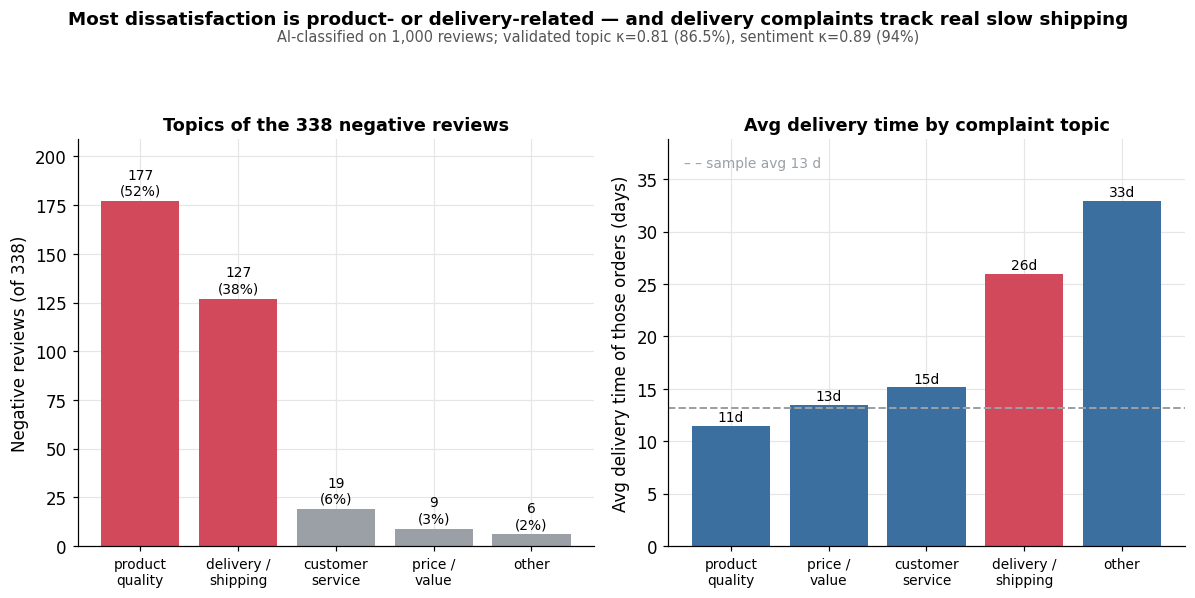

In [ ]:
brk=pd.read_csv(OUT/"ai_topic_breakdown.csv")
rc_ai=pd.read_csv(ROOT/"ai"/"review_classification.csv"); base_days=rc_ai["delivery_days"].mean()
LAB={"delivery_shipping":"delivery /\nshipping","product_quality":"product\nquality","customer_service":"customer\nservice","price_value":"price /\nvalue","other":"other"}
brk["label"]=brk["topic"].map(LAB)
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.0,5.2))
colors=[HI if t in ("delivery_shipping","product_quality") else GRAY for t in brk["topic"]]
a1.bar(range(len(brk)),brk["n"],color=colors)
for i,r in brk.reset_index().iterrows():
    a1.annotate(f"{int(r['n'])}\n({r['pct_of_negatives']:.0f}%)",(i,r["n"]),textcoords="offset points",xytext=(0,4),ha="center",fontsize=9)
a1.set_xticks(range(len(brk))); a1.set_xticklabels(brk["label"],fontsize=9); a1.set_ylabel("Negative reviews (of 338)")
a1.set_ylim(0,brk["n"].max()*1.18); a1.set_title("Topics of the 338 negative reviews",fontsize=11.5)
order=brk.sort_values("avg_delivery_days"); colors2=[HI if t=="delivery_shipping" else BLUE for t in order["topic"]]
a2.bar(range(len(order)),order["avg_delivery_days"],color=colors2); a2.axhline(base_days,color=GRAY,ls="--",lw=1.3)
a2.text(0.03,0.93,f"– – sample avg {base_days:.0f} d",transform=a2.transAxes,fontsize=9,color=GRAY)
for i,r in order.reset_index().iterrows():
    a2.annotate(f"{r['avg_delivery_days']:.0f}d",(i,r["avg_delivery_days"]),textcoords="offset points",xytext=(0,3),ha="center",fontsize=9)
a2.set_xticks(range(len(order))); a2.set_xticklabels(order["topic"].map(LAB),fontsize=9)
a2.set_ylabel("Avg delivery time of those orders (days)"); a2.set_ylim(0,order["avg_delivery_days"].max()*1.18); a2.set_title("Avg delivery time by complaint topic",fontsize=11.5)
fig.suptitle("Most dissatisfaction is product- or delivery-related — and delivery complaints track real slow shipping",fontsize=12,fontweight="bold",y=1.04)
fig.text(0.5,0.985,"AI-classified on 1,000 reviews; validated topic κ=0.81 (86.5%), sentiment κ=0.89 (94%)",ha="center",fontsize=9.5,color="#555555")
fig.tight_layout(rect=[0,0,1,0.95]); savefig(fig,"fig8_ai_topic_breakdown.png"); plt.show()

## 8 · Reconciliation, conclusion & limits

**Right on the total only if you're careful.** Built on the correct order grain, the marketplace is
seasonal (Nov peak), revenue is concentrated (few categories, São Paulo), satisfaction is driven by the
delivery tail (structured **and** in customers' words), and it runs on acquisition with ~3% repeat. Build the
same numbers from a naïve join and revenue/AOV inflate — which is the whole point: **the data-quality layer
is what makes the dashboard trustworthy.**

**Limitations (carried into the report).** 2016–2018 Brazilian-marketplace snapshot — don't generalize to now
or other markets; cleaning choices are documented, reversible assumptions; AI labels are validated on a
sample, not exhaustive; delivery↔score is a strong association, not proven causation; geolocation deduped by
approximation.

**Artifacts.** Tableau-ready tables in `data/output/`; QA tracker, data dictionary, and methodology in
`documentation/`; the AI validation in `ai/validation_report.md`; and the polished, figure-embedded write-up
in **`reports/Olist_Analyst_Report.docx`**.